In [1]:
import os
import time
from datetime import datetime
import src.phasebalance.phase_unbalance_utils as m
from typing import Optional, Tuple
import pandas as pd
import numpy as np
import src.phasebalance.janitza_report_device as jrd

from typing import Sequence, Optional, Tuple
try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle
except Exception:  # matplotlib not available
    plt = None
    Circle = None

PATTERN = (
    r"Measurement Group 2|Measurement Group 3|Mod 1|Mod1|Mod2|Mod3|Mod\. 1|Mod\. 2|LR|241|"
    r"Device-4|Device-233|Device-162"
)

def _severity_donut_for_metric(
    df: pd.DataFrame,
    metric: str,
    threshold: float,      # kept for API-compatibility; intentionally unused
    outdir: str,           # kept for API-compatibility; intentionally unused
    per_device: bool = True,
    agg: str = "median",
    labels: Tuple[str, str, str, str] = ("Low", "Medium", "High", "Extreme"),
    *,
    low: float = 0.15,
    mid: float = 0.30,
    high: float = 0.50,
):
    """
    Doughnut chart showing severity breakdown for `metric`.

    Bins (custom edges):
      Low     : value < low
      Medium  : low <= value < mid
      High    : mid <= value < high
      Extreme : value >= high

    Notes:
    - `threshold` and `outdir` are accepted to keep the same call signature as before,
      but are not used.
    """
    if plt is None or Circle is None:
        print("matplotlib not available; skipping severity doughnut.")
        return None
    if metric not in df.columns:
        print(f"[{metric}] not found; skipping severity doughnut.")
        return None

    # sanity check for thresholds
    low = float(low)
    mid = float(mid)
    high = float(high)
    if not (low < mid < high):
        raise ValueError(f"Expected low < mid < high, got low={low}, mid={mid}, high={high}")

    # choose the series to bin
    ser = pd.to_numeric(df[metric], errors="coerce").dropna()
    if ser.empty:
        print(f"[{metric}] no numeric values; skipping severity doughnut.")
        return None

    if per_device and "device_id" in df.columns:
        g = df.dropna(subset=[metric]).copy()
        g[metric] = pd.to_numeric(g[metric], errors="coerce")

        agg_map = {"median": "median", "mean": "mean", "max": "max", "min": "min"}
        if agg not in agg_map:
            raise ValueError(f"Unsupported agg='{agg}'")

        ser = getattr(g.groupby("device_id")[metric], agg_map[agg])().dropna()

    if ser.empty:
        print(f"[{metric}] aggregation produced no data; skipping.")
        return None

    # 4 bins: (-inf, low), [low, mid), [mid, high), [high, +inf)
    bins = [float("-inf"), low, mid, high, float("inf")]
    cats = pd.cut(
        ser.astype(float).to_numpy(),
        bins=bins,
        labels=list(labels),
        right=False,
        include_lowest=True,
    )

    counts = pd.Series(cats).value_counts().reindex(list(labels), fill_value=0)
    if int(counts.sum()) == 0:
        print(f"[{metric}] no counts in any bin; skipping.")
        return None

    counts_np = counts.astype(int).to_numpy()

    # Colors (Extreme = purple)
    colors = ["#ccebc5", "#fdb462", "#fb8072", "#8e44ad"]

    fig, ax = plt.subplots(figsize=(7, 7))
    # -------------------------
    # PLACE THIS BLOCK HERE
    # -------------------------
    total = counts_np.sum()
    min_label_pct = 3.0  # hide on-pie labels below this %

    pie_labels = []
    legend_labels = []
    for lab, n in zip(counts.index, counts_np):
        pct = (n / total * 100.0) if total > 0 else 0.0
        legend_labels.append(f"{lab} ({n}, {pct:.1f}%)")
        pie_labels.append(f"{lab}\n{n}" if (n > 0 and pct >= min_label_pct) else "")

    wedges, texts = ax.pie(
        counts_np,
        labels=pie_labels,
        startangle=90,
        colors=colors,
        autopct=None,
        labeldistance=1.10,
        rotatelabels=True,
    )

    ax.legend(
        wedges,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        title="Bins",
    )
    # -------------------------
    # END BLOCK
    # -------------------------

    centre_circle = Circle((0, 0), 0.60, fc="white")
    ax.add_artist(centre_circle)
    ax.axis("equal")
    ax.set_title(
        f"{metric}: severity breakdown "
        f"({'per feeder ' + agg if per_device else 'all rows'}) "
        f"[low<{low}, mid<{mid}, high<{high}]"
    )

    fig.tight_layout()
    return fig

def barplot_by_device(
    df: pd.DataFrame,
    metric: str,
    outdir: str,                 # kept for API-compatibility; intentionally unused
    top_n: int | None = None,
):
    """
    Create a bar chart of `metric` vs device_id.

    Works if device_id is:
      - a column (device_id / deviceId / Device_ID / etc.), OR
      - the index (index.name == 'device_id'), OR
      - a MultiIndex level named 'device_id'.

    Returns a matplotlib Figure (not saved, not closed). None if skipped.
    """
    if plt is None:
        print("matplotlib not available; skipping plots.")
        return None

    if metric not in df.columns:
        print(f"[{metric}] metric column missing; skipping.")
        return None

    # ---- Find device ids (column OR index) ----
    candidates = ("device_id", "deviceId", "deviceID", "Device_ID", "DeviceId")

    # 1) Try columns (robust to whitespace)
    cols = {str(c).strip(): c for c in df.columns}  # stripped -> original
    device_col = next((cols[c] for c in candidates if c in cols), None)

    if device_col is not None:
        device_ids = df[device_col]
    else:
        # 2) Try index
        idx = df.index
        if isinstance(idx, pd.MultiIndex):
            if "device_id" in idx.names:
                device_ids = idx.get_level_values("device_id")
            else:
                print(f"[{metric}] device_id not found in columns or MultiIndex levels; skipping.")
                return None
        else:
            if idx.name in candidates:
                device_ids = idx
            else:
                print(f"[{metric}] device_id not found in columns or index name; skipping.")
                return None

    sub = pd.DataFrame(
        {
            "device_id": device_ids.astype(str).to_numpy(),
            metric: pd.to_numeric(df[metric], errors="coerce").to_numpy(),
        }
    ).dropna(subset=[metric])

    # sort by metric desc (stable sort)
    sub = sub.sort_values(metric, ascending=False, kind="mergesort")

    if top_n is not None:
        sub = sub.head(top_n)

    n = len(sub)
    if n == 0:
        print(f"[{metric}] No valid data to plot.")
        return None

    width = min(max(10, int(n * 0.25)), 36)
    height = 6

    fig, ax = plt.subplots(figsize=(width, height))
    ax.bar(sub["device_id"], sub[metric])
    ax.set_ylabel(metric)
    ax.set_xlabel("device_id")
    ax.set_title(f"{metric} by device_id (n={n})")
    ax.tick_params(axis="x", rotation=90)
    fig.tight_layout()
    return fig

def _select_device(df_jn: pd.DataFrame, device_id) -> pd.DataFrame:
    col = df_jn["device_id"]

    # 1) Try numeric match
    col_num = pd.to_numeric(col, errors="coerce")
    try:
        target_num = float(device_id)
    except Exception:
        target_num = None

    if target_num is not None:
        mask = col_num == target_num
        if mask.any():
            return df_jn.loc[mask].copy()

    # 2) Fallback: string-normalized match (handles " 5", "005", "5.0", "D0005")
    target = str(device_id).strip()
    col_s = col.astype(str).str.strip()

    # if values look like D0411, extract digits
    col_digits = col_s.str.extract(r"(\d+)", expand=False)
    target_digits = pd.Series([target]).str.extract(r"(\d+)", expand=False).iloc[0]

    if pd.notna(target_digits):
        mask = col_digits.fillna("") == target_digits
        if mask.any():
            return df_jn.loc[mask].copy()

    # last resort exact string compare
    mask = col_s == target
    return df_jn.loc[mask].copy()

def df_jn_to_report_df(
    df_jn: pd.DataFrame,
    device_id: int,
    metric_col: str = "cur_ratio",
    stat: str = "avg",                 # use Ia_avg/Ib_avg/... (or "min"/"max")
    start: str | None = None,
    end: str | None = None,
    scale: str = "auto",               # "auto" | "fraction_to_percent" | "none"
) -> pd.DataFrame:
    df = _select_device(df_jn, device_id)
    if df.empty:
        # show what "5" looks like in the column to diagnose immediately
        sample = df_jn["device_id"].astype(str).str.strip().unique()[:30]
        raise ValueError(f"No rows for device_id={device_id}. Sample device_id values: {sample}")

    df["ts"] = pd.to_datetime(df["ts"])
    df = df.set_index("ts").sort_index()

    if start is not None:
        df = df.loc[pd.to_datetime(start):]
    if end is not None:
        df = df.loc[:pd.to_datetime(end)]

    # If you have duplicates on ts (can happen with windowed outputs), keep last or aggregate
    df = df[~df.index.duplicated(keep="last")]

    # Rename chosen stat columns -> Ia/Ib/Ic (and optionally Va/Vb/Vc)
    rename = {
        f"Ia_{stat}": "Ia",
        f"Ib_{stat}": "Ib",
        f"Ic_{stat}": "Ic",
        f"Va_{stat}": "Va",
        f"Vb_{stat}": "Vb",
        f"Vc_{stat}": "Vc",
    }
    missing_curr = [c for c in (f"Ia_{stat}", f"Ib_{stat}", f"Ic_{stat}") if c not in df.columns]
    if missing_curr:
        raise ValueError(f"Missing current columns for stat='{stat}': {missing_curr}")

    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

    # Ensure numeric
    for c in ("Ia", "Ib", "Ic", "Va", "Vb", "Vc"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Build the columns the report expects
    df["I_sum"] = df[["Ia", "Ib", "Ic"]].sum(axis=1)
    df["I_max"] = df[["Ia", "Ib", "Ic"]].max(axis=1)
    df["I_min"] = df[["Ia", "Ib", "Ic"]].min(axis=1)

    if metric_col not in df.columns:
        raise ValueError(f"metric_col='{metric_col}' not in df columns")

    imb = pd.to_numeric(df[metric_col], errors="coerce")

    # Scale: your notebook thresholds (0.15/0.30/0.50) strongly suggest "fraction", not "percent"
    if scale == "fraction_to_percent":
        imb = imb * 100.0
    elif scale == "auto":
        # heuristic: if values look like fractions (<= 2), treat as fraction->percent
        q = float(imb.quantile(0.99)) if imb.notna().any() else np.nan
        if np.isfinite(q) and q <= 2.0:
            imb = imb * 100.0

    df["imbalance"] = imb

    # NOTE: your jrd.label_culprit_pair currently has a bug (see next section).
    # We'll compute culprit_pair robustly here (no need to edit jrd yet).
    def culprit_pair(row):
        hi = row[["Ia","Ib","Ic"]].idxmax()
        lo = row[["Ia","Ib","Ic"]].idxmin()
        canon = {
            "IaIb": "Ia-Ib", "IbIa": "Ia-Ib",
            "IbIc": "Ib-Ic", "IcIb": "Ib-Ic",
            "IcIa": "Ic-Ia", "IaIc": "Ic-Ia",
        }
        return canon.get(f"{hi}{lo}", "Ia-Ib")

    df["dominant_phase"] = df[["Ia", "Ib", "Ic"]].idxmax(axis=1)
    df["culprit_pair"] = df.apply(culprit_pair, axis=1)

    df = df.dropna(subset=["Ia", "Ib", "Ic", "imbalance"])
    return df

def _plot_phase_currents_timeseries(
    df: pd.DataFrame,
    device_id: int,
    dpi: int,
    out_path: str,
    *,
    title: str | None = None,
):
    """
    Plot Ia/Ib/Ic vs timestamp (one device), save to out_path.
    Expects df indexed by ts and containing columns: Ia, Ib, Ic.
    """
    if plt is None:
        print("matplotlib not available; skipping phase current plot.")
        return None

    need = ["Ia", "Ib", "Ic"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        print(f"Missing {missing}; skipping phase current plot.")
        return None

    fig, ax = plt.subplots(figsize=(12, 4), dpi=dpi)
    ax.plot(df.index, df["Ia"], linewidth=1.2, label="Ia")
    ax.plot(df.index, df["Ib"], linewidth=1.2, label="Ib")
    ax.plot(df.index, df["Ic"], linewidth=1.2, label="Ic")

    ax.set_xlabel("Time")
    ax.set_ylabel("Current (A)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    if title is None:
        title = f"Device {device_id}: Phase currents"
    ax.set_title(title)

    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi)
    # do NOT close here if you want it displayed in notebooks; otherwise uncomment:
    # plt.close(fig)
    return fig

def make_7_plots_from_df_jn(
    df_jn: pd.DataFrame,
    device_id: int,
    metric_col: str,
    thresholds: dict,           # mild/moderate/severe in SAME units as df["imbalance"]
    outdir: str,
    dpi: int = 200,
    timebase: str = "15min",
    stat: str = "avg",
    start: str | None = None,
    end: str | None = None,
    scale: str = "auto",
):
    os.makedirs(outdir, exist_ok=True)

    df = df_jn_to_report_df(
        df_jn, device_id,
        metric_col=metric_col,
        stat=stat,
        start=start, end=end,
        scale=scale,
    )

    sample_delta = jrd._compute_sample_delta(timebase, df.index)

    events_records = {}
    for band, thr in thresholds.items():
        ev_idx = jrd.detect_events(
            df["imbalance"],
            tau_on=float(thr),
            tau_off=float(thr) * 0.9,
            gap_merge=1,
            min_len=2,
        )
        events_records[band] = jrd.summarise_events(df, ev_idx, sample_delta)

    mild_events = events_records.get("mild", [])

    # Pick a nice label
    metric_name = metric_col + (" (%)" if df["imbalance"].max() > 2 else "")

    # 1) colored time-series (imbalance with culprit colors)
    jrd.plot_colored_cur(
        df, thresholds, device_id, metric_name,
        str(df.index.min()), str(df.index.max()),
        dpi, os.path.join(outdir, "01_colored_cur.png")
    )

    # 2) NEW: phase currents over time (Ia/Ib/Ic)
    _plot_phase_currents_timeseries(
        df,
        device_id=device_id,
        dpi=dpi,
        out_path=os.path.join(outdir, "02_phase_currents.png"),
        title=f"Device {device_id}: Ia/Ib/Ic ({stat})",
    )

    # shift the old numbering down by +1
    jrd.plot_event_stripes(
        mild_events, device_id, metric_name, str(df.index.min()), str(df.index.max()),
        dpi, os.path.join(outdir, "03_event_stripes.png"), sample_delta
    )
    jrd.plot_severity_duration_scatter(
        mild_events, device_id, metric_name,
        dpi, os.path.join(outdir, "04_severity_duration_scatter.png")
    )
    jrd.plot_diurnal_heatmap(
        df, device_id, metric_name,
        dpi, os.path.join(outdir, "05_diurnal_heatmap.png")
    )

    metrics = {
        "overall_peak": float(df["imbalance"].max()),
        "overall_p95": float(df["imbalance"].quantile(0.95)),
        "overall_p99": float(df["imbalance"].quantile(0.99)),
    }
    metrics.update(jrd.summarise_bands(df, df["imbalance"], events_records, thresholds, sample_delta))

    jrd.plot_exceedance_and_taat(
        df["imbalance"], thresholds, metrics, device_id, metric_name,
        dpi, os.path.join(outdir, "06_exceedance_and_taat.png")
    )

    jrd.plot_ternary(
        df, device_id,
        dpi, os.path.join(outdir, "07_ternary.png")
    )

    return df, mild_events, metrics


devices_list = "../metadata/devices.csv" 
df_devices = pd.read_csv(devices_list) # Here I load up the device metadata that tells me what device is in what measurement group
janitza_path = "../data/janitza_timeseries_2026-01-23_1936_All_mes.parquet"#../results/janitza_timeseries_2026-01-10_1738.parquet"
df_jn = pd.read_parquet(janitza_path)


# Multiply the 'vuf_magnitude' column by 100 this is a temp fix since I forgot to do it in the phase unbalance utils file but I fixed so going forward it will be correct.
#df_jn['vuf_magnitude'] = df_jn['vuf_magnitude'] * 100

print(
    "Initial number of rows in df_jn before filtering out measurement group 2 and 3: "
    f"{len(df_jn)}"
)

df_jn_filtered, devices_to_remove = m.filter_devices_by_name_pattern(df_jn,df_devices,pattern=PATTERN,)

before_rows = len(df_jn_filtered)
print(f"Rows removed from df_jn : {len(df_jn) - len(df_jn_filtered)}")
print("Remaining rows in df_jn_filtered after the removal of measurement group 2 and 3 "f"from df_jn: {before_rows}")

before_devs = df_jn_filtered["device_id"].nunique()
df_jn_hi_load = m.filter_low_load_samples(df_jn_filtered,use_isum=True,isum_min_A=90,min_valid_points_per_device=0,)
after_rows = len(df_jn_hi_load)
after_devs = df_jn_hi_load["device_id"].nunique()

print(f"Rows before in df_jn_filtered: {before_rows:,} |  after removal of low current readings: {after_rows:,}  (removed {(before_rows-after_rows):,})")
print(f"Unique devices before removal of low current in df_jn_filtered: {before_devs:,} | after (present in hi-load rows): {after_devs:,}")
print(f"Kept fraction of samples: {after_rows / max(before_rows,1):.3f}")

#device 232 aka D1299 SP1 L1 might be somthing to throw out seem like only one phase has a non zerp reading might be faulty sensor

Initial number of rows in df_jn before filtering out measurement group 2 and 3: 1024769
Rows removed from df_jn : 275915
Remaining rows in df_jn_filtered after the removal of measurement group 2 and 3 from df_jn: 748854
Rows before in df_jn_filtered: 748,854 |  after removal of low current readings: 613,646  (removed 135,208)
Unique devices before removal of low current in df_jn_filtered: 83 | after (present in hi-load rows): 81
Kept fraction of samples: 0.819


In [2]:
device_type_counts = df_jn.groupby('device_type_name')['device_id'].nunique().sort_values(ascending=False)
print(device_type_counts)

device_type_name
UMG 801 Measurement Group    68
UMG 96RM-E                   40
UMG 605                       4
UMG 512                       2
UMG 96-PQ-L                   1
Name: device_id, dtype: int64


In [3]:
device_type_counts = df_jn['device_id'].nunique()
print(device_type_counts)

115


In [5]:
# Group by device_id and calculate the mean for the specified columns
avg_df = df_jn_hi_load.groupby('device_id')[['Ia_avg', 'Ib_avg', 'Ic_avg', 'Va_avg', 'Vb_avg', 'Vc_avg']].mean()

results = []
for idx, row in avg_df.iterrows():
    res = m.compute_meter_metrics(
        Ia=row['Ia_avg'],
        Ib=row['Ib_avg'],
        Ic=row['Ic_avg'],
        Va_mag=row['Va_avg'],
        Vb_mag=row['Vb_avg'],
        Vc_mag=row['Vc_avg']
    )
    results.append(res)

metrics_df = pd.DataFrame(results, index=avg_df.index)
avg_df = pd.concat([avg_df, metrics_df], axis=1)

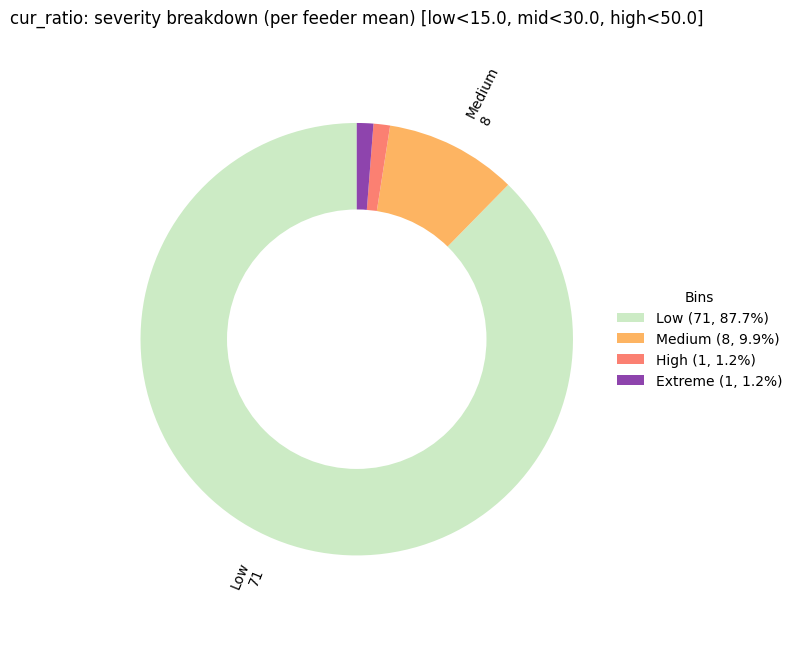

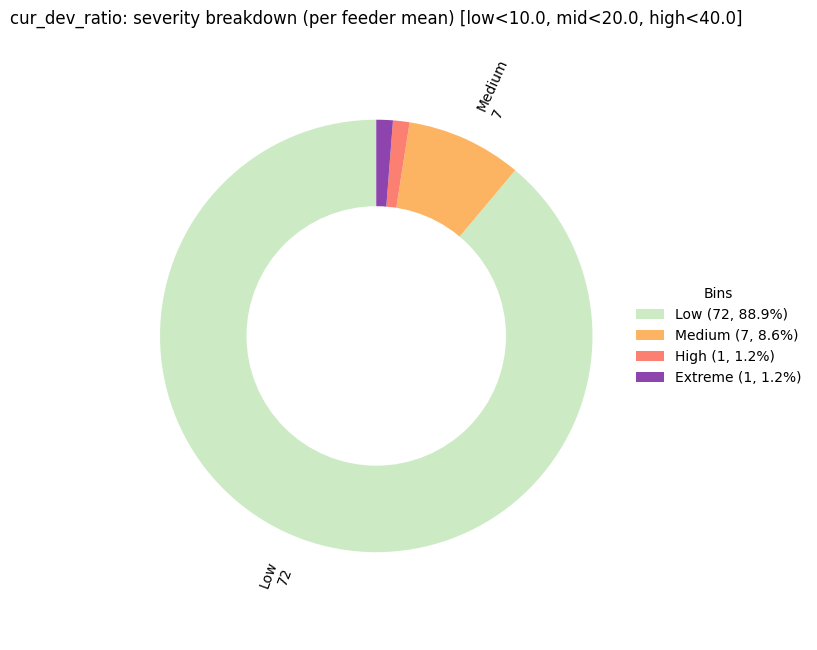

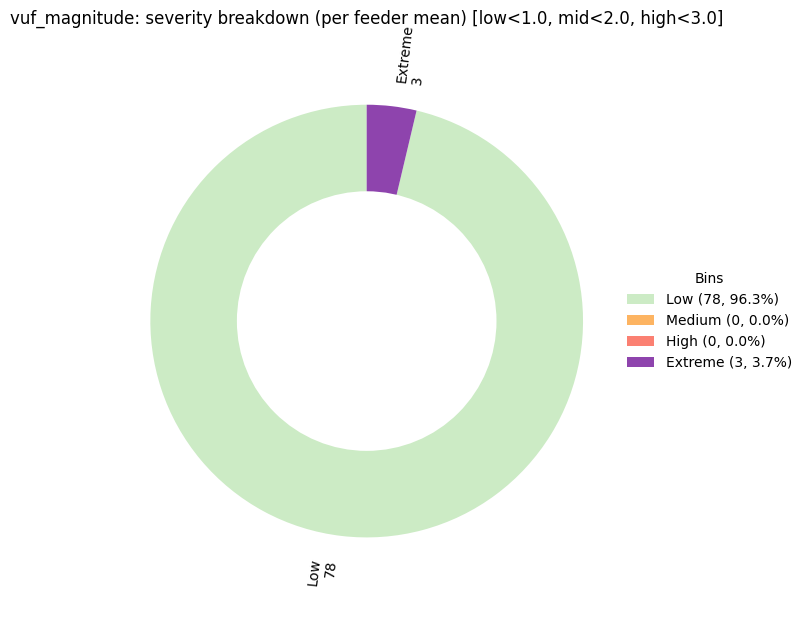

In [6]:
# Here all the thresholds are for the long-term analysis where we average per feeder over the entire measurement period
LongTerm_low_CUR = 15
LongTerm_mid_CUR = 30
LongTerm_high_CUR = 50

LongTerm_low_CUR_d = 10
LongTerm_mid_CUR_d = 20
LongTerm_high_CUR_d = 40

LongTerm_low_VUF = 1
LongTerm_mid_VUF = 2
LongTerm_high_VUF = 3

fig = _severity_donut_for_metric(avg_df, "cur_ratio", threshold=0, outdir=".", per_device=True, agg="mean", low=LongTerm_low_CUR, mid=LongTerm_mid_CUR, high=LongTerm_high_CUR)
fig = _severity_donut_for_metric(avg_df, "cur_dev_ratio", threshold=0, outdir=".", per_device=True, agg="mean", low=LongTerm_low_CUR_d, mid=LongTerm_mid_CUR_d, high=LongTerm_high_CUR_d)
fig = _severity_donut_for_metric(avg_df, "vuf_magnitude", threshold=0, outdir=".", per_device=True, agg="mean", low=LongTerm_low_VUF, mid=LongTerm_mid_VUF, high=LongTerm_high_VUF)


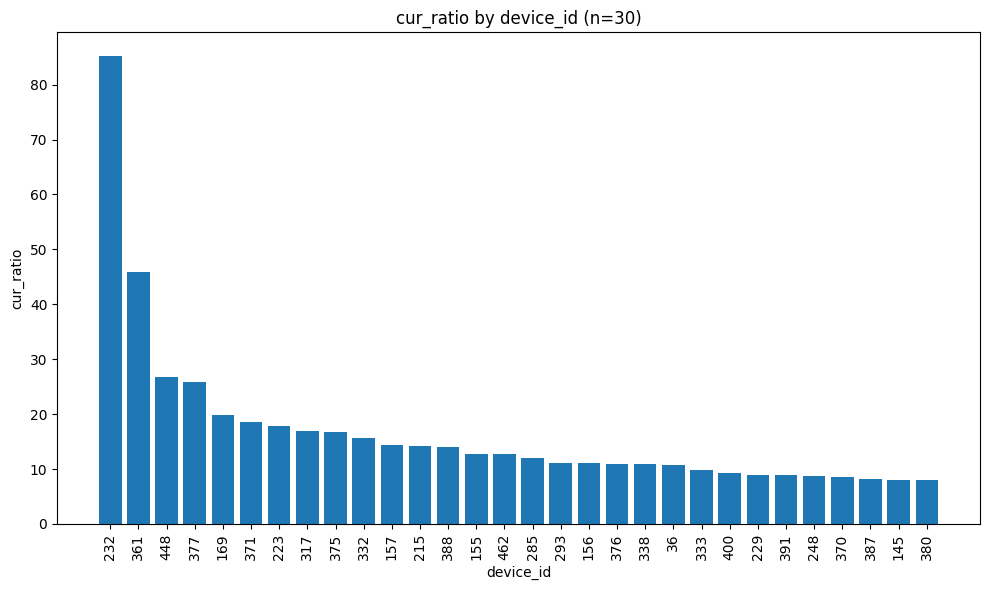

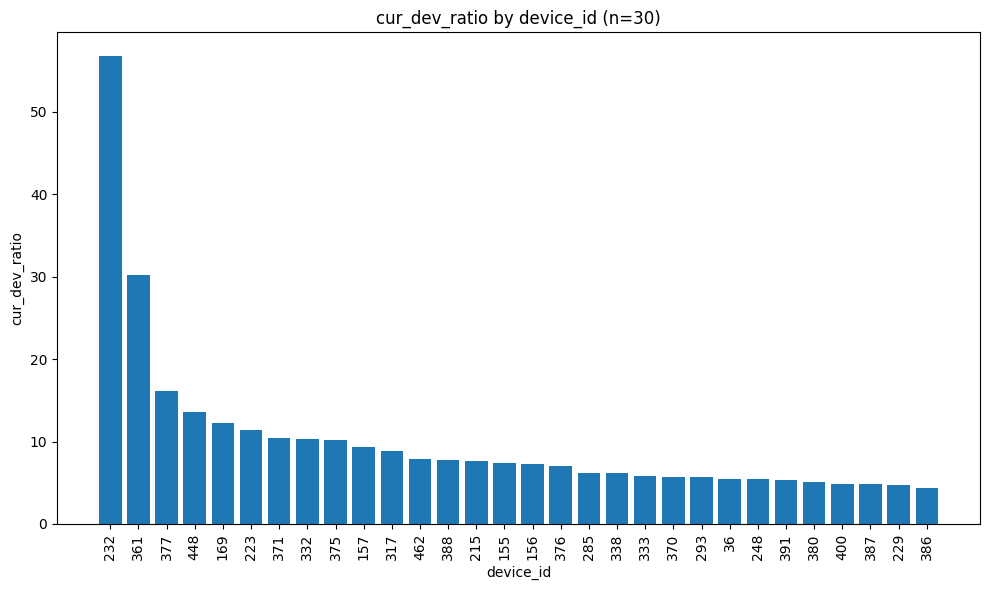

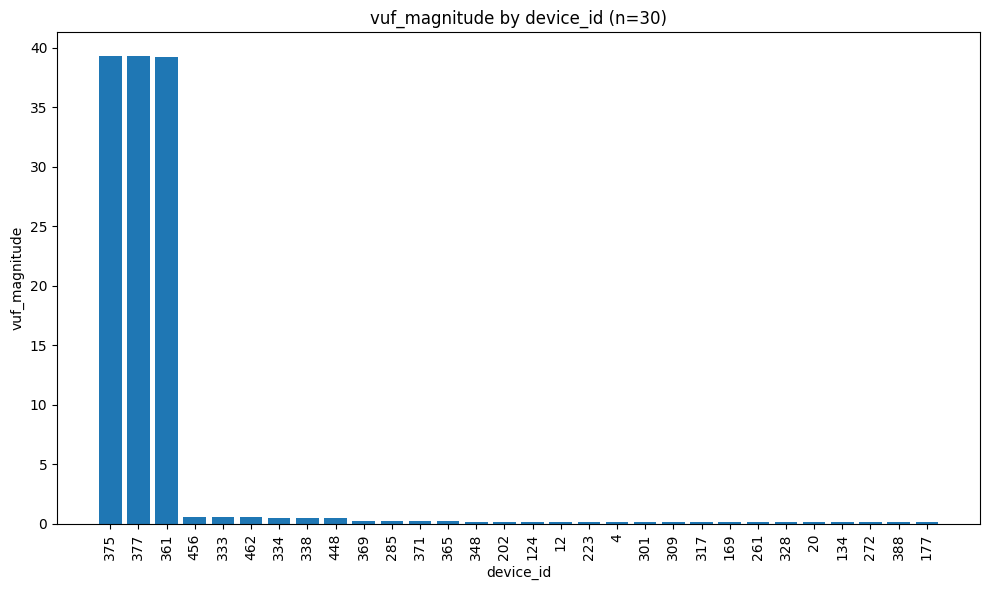

In [7]:
fig = barplot_by_device(avg_df, "cur_ratio", outdir=".", top_n=30)  # outdir ignored
fig = barplot_by_device(avg_df, "cur_dev_ratio", outdir=".", top_n=30) 
fig = barplot_by_device(avg_df, "vuf_magnitude", outdir=".", top_n=30)

## Per Timestamp Analysis (15min)

Here we look at the data in 15 min intervals.

FYI device 377/375/361 is causing the random spike in VUF

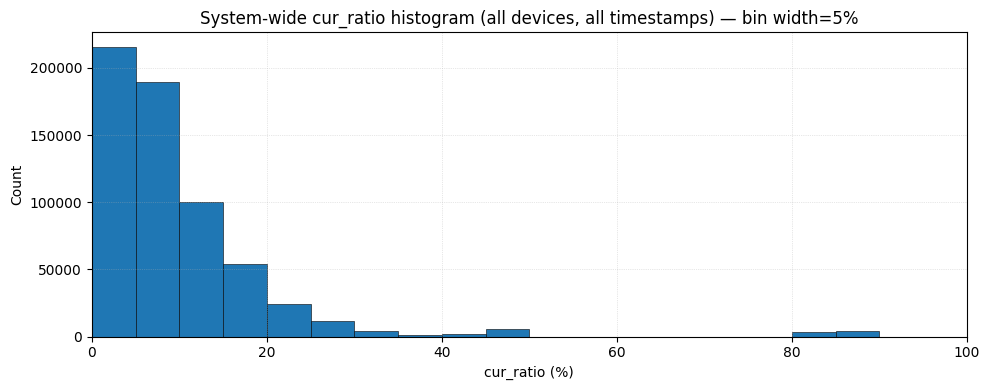

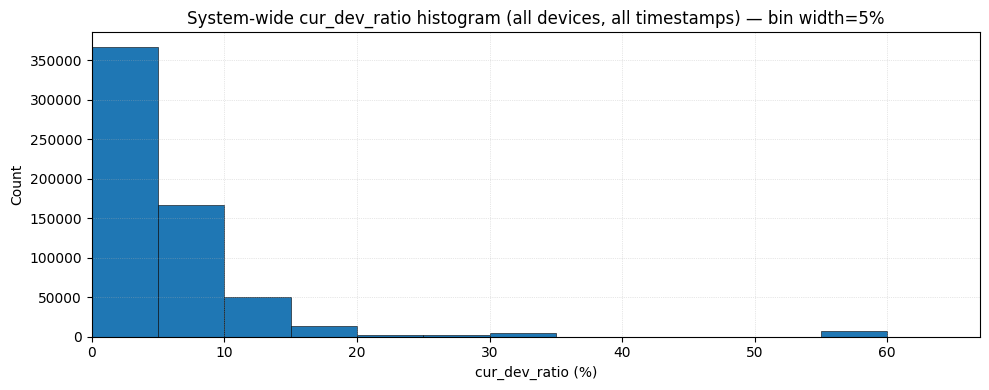

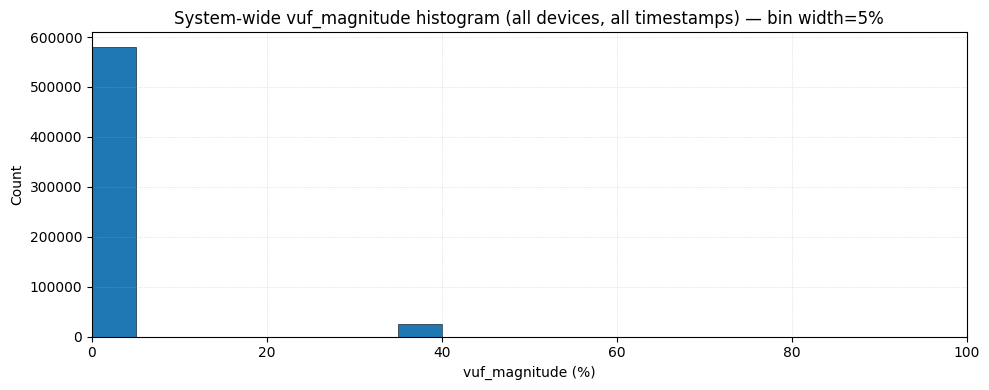

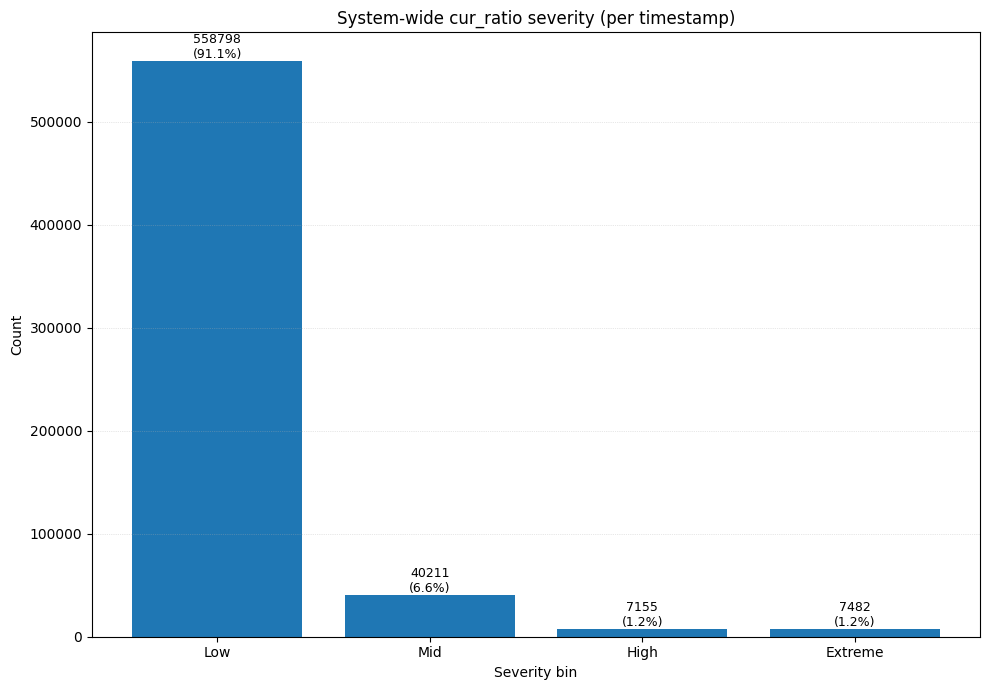

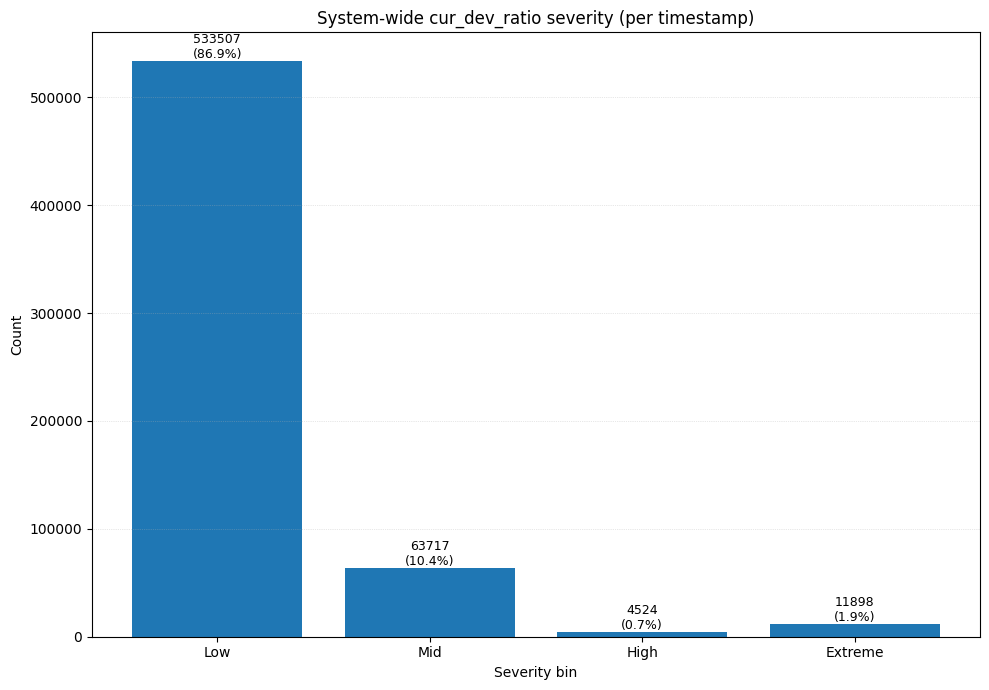

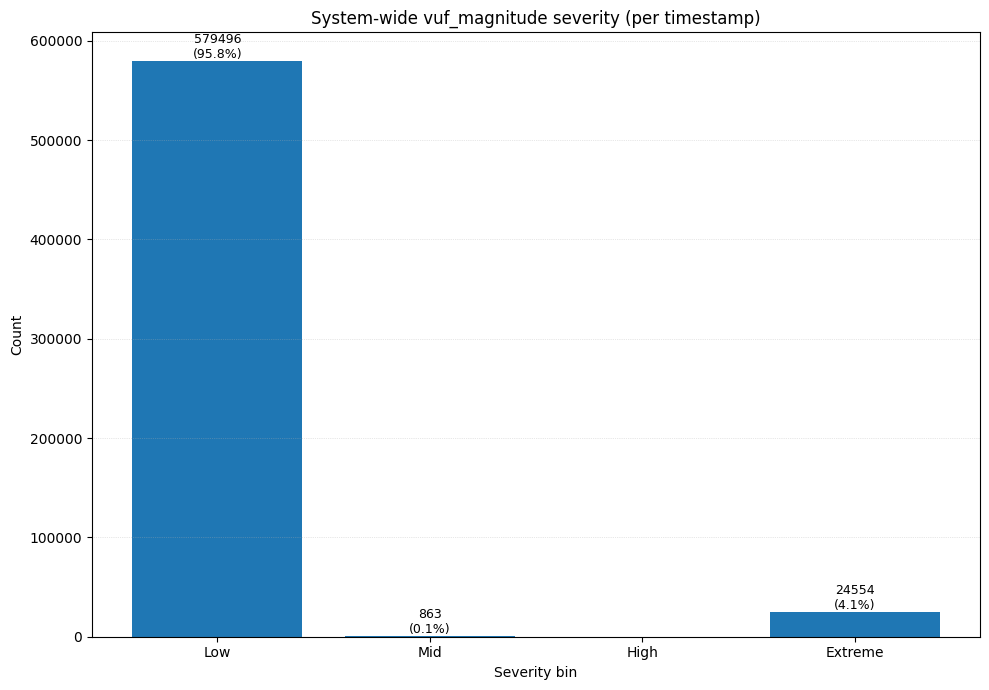

In [8]:

def system_wide_histogram(
    df_jn: pd.DataFrame,
    metric_col: str = "cur_ratio",
    bin_width_pct: float = 5.0,
    max_pct: float = 100.0,
    stat: str | None = None,        # unused, kept for symmetry
):
    """
    Histogram of `metric_col` over *all rows* (all devices, all timestamps).
    Bins are bin_width_pct wide (default 5%).
    """
    if plt is None:
        print("matplotlib not available.")
        return None

    vals = pd.to_numeric(df_jn[metric_col], errors="coerce").dropna()
    vals = vals[(vals >= 0) & (vals <= max_pct)]
    if vals.empty:
        raise ValueError(f"No valid {metric_col} values in [0, {max_pct}]")

    edges = np.arange(0, max_pct + bin_width_pct, bin_width_pct)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(vals.to_numpy(), bins=edges, edgecolor="k", linewidth=0.4)
    ax.set_xlabel(f"{metric_col} (%)")
    ax.set_ylabel("Count")
    ax.set_title(f"System-wide {metric_col} histogram (all devices, all timestamps) — bin width={bin_width_pct}%")
    ax.set_xlim(0, max_pct)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
    fig.tight_layout()
    return fig

def system_wide_severity_barchart_timestamp(
    df_jn: pd.DataFrame,
    metric_col: str = "cur_ratio",
    *,
    edges: Sequence[float],                # e.g. [0, 20, 40, 60, 100.000001]
    labels: Optional[Sequence[str]] = None,# e.g. ["Low","Mid","High","Extreme"]
    max_pct: float = 100.0,
    dropna_ts: bool = True,
    annotate_percent: bool = True,
):
    """
    System-wide severity bar chart computed over *raw timestamps* (no hourly resampling).

    - Each row (device_id, ts) contributes one sample.
    - Bins are controlled by `edges` (and optional `labels`).

    Binning convention:
      - Uses right=False => intervals are [a, b)
      - Last edge should typically be > max_pct to include max_pct cleanly,
        e.g. edges=[0, 20, 40, 60, max_pct + 1e-9]
    """
    if plt is None:
        print("matplotlib not available.")
        return None, None, None

    if "ts" not in df_jn.columns:
        raise ValueError("df_jn must contain a 'ts' column.")
    if "device_id" not in df_jn.columns:
        raise ValueError("df_jn must contain a 'device_id' column.")
    if metric_col not in df_jn.columns:
        raise ValueError(f"metric_col='{metric_col}' not found in df_jn.")

    edges = [float(x) for x in edges]
    if len(edges) < 3:
        raise ValueError("edges must have at least 3 values (e.g., [0, mid, max]).")
    if any(edges[i] >= edges[i+1] for i in range(len(edges)-1)):
        raise ValueError(f"edges must be strictly increasing. Got: {edges}")

    nbins = len(edges) - 1
    if labels is None:
        labels = [f"Bin{i+1}" for i in range(nbins)]
    else:
        labels = list(labels)
        if len(labels) != nbins:
            raise ValueError(f"labels must have length {nbins} (len(edges)-1). Got {len(labels)}")

    tmp = df_jn[["device_id", "ts", metric_col]].copy()
    tmp["ts"] = pd.to_datetime(tmp["ts"], errors="coerce")
    tmp["device_id"] = pd.to_numeric(tmp["device_id"], errors="coerce").astype("Int64")
    tmp[metric_col] = pd.to_numeric(tmp[metric_col], errors="coerce")

    if dropna_ts:
        tmp = tmp.dropna(subset=["device_id", "ts", metric_col])
    else:
        tmp = tmp.dropna(subset=["device_id", metric_col])

    vals = tmp[metric_col].to_numpy(dtype=float)
    vals = vals[(vals >= 0) & (vals <= max_pct)]
    if vals.size == 0:
        raise ValueError(f"No valid per-timestamp {metric_col} values in [0, {max_pct}]")

    cats = pd.cut(
        vals,
        bins=edges,
        labels=labels,
        right=False,          # [a,b)
        include_lowest=True,
    )

    counts = pd.Series(cats).value_counts().reindex(labels, fill_value=0)
    total = int(counts.sum())

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.bar(labels, counts.to_numpy())
    ax.set_xlabel("Severity bin")
    ax.set_ylabel("Count")
    ax.set_title(f"System-wide {metric_col} severity (per timestamp)")
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

    # annotate counts (+ percent)
    for i, lab in enumerate(labels):
        v = int(counts.loc[lab])
        if v == 0:
            continue
        if annotate_percent:
            pct = (v / total * 100.0) if total > 0 else 0.0
            ax.text(i, v, f"{v}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
        else:
            ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    return fig, counts, tmp



edges_ts_CUR = [0.0, 20.0, 40.0, 60.0, 100.0 + 1e-9]
edges_ts_CURdev = [0.0, 10, 20, 30, (2/3)*100 + 1e-9]
edges_ts_VUF = [0.0, 1, 2, 3, 100 + 1e-9]
labels = ["Low", "Mid", "High", "Extreme"]

fig = system_wide_histogram(df_jn_hi_load, metric_col="cur_ratio", bin_width_pct=5, max_pct=100)
fig = system_wide_histogram(df_jn_hi_load, metric_col="cur_dev_ratio", bin_width_pct=5, max_pct=67)
fig = system_wide_histogram(df_jn_hi_load, metric_col="vuf_magnitude", bin_width_pct=5, max_pct=100)


fig, counts, tmp = system_wide_severity_barchart_timestamp(
    df_jn_hi_load,
    metric_col="cur_ratio",
    edges=edges_ts_CUR,
    labels=labels,
    max_pct=100.0,
)

fig, counts, tmp = system_wide_severity_barchart_timestamp(
    df_jn_hi_load,
    metric_col="cur_dev_ratio",
    edges=edges_ts_CURdev,
    labels=labels,
    max_pct=67,
)

fig, counts, tmp = system_wide_severity_barchart_timestamp(
    df_jn_hi_load,
    metric_col="vuf_magnitude",
    edges=edges_ts_VUF,
    labels=labels,
    max_pct=100,
)


## Hourly Analysis

Here we look at the data in 1 hour intervals.

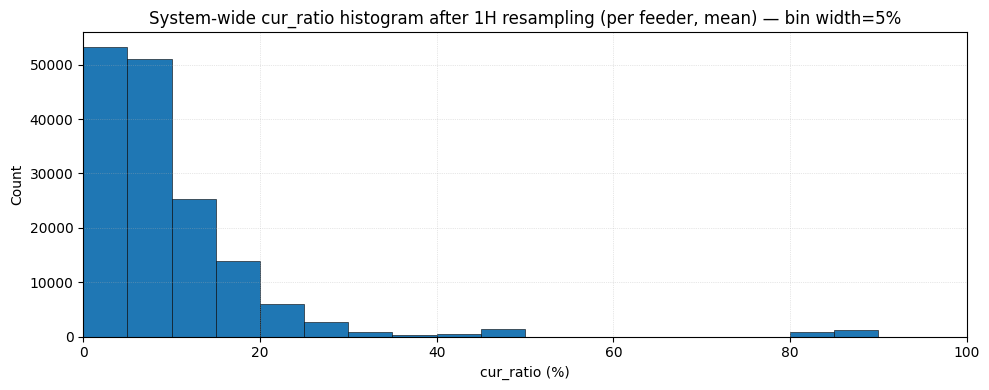

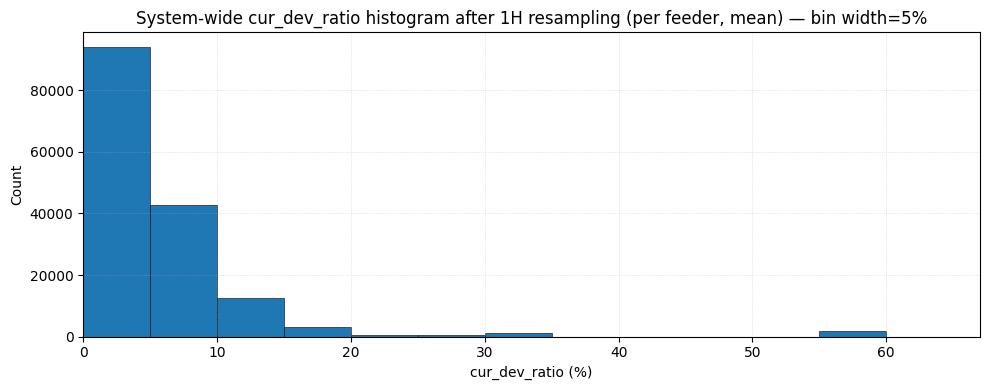

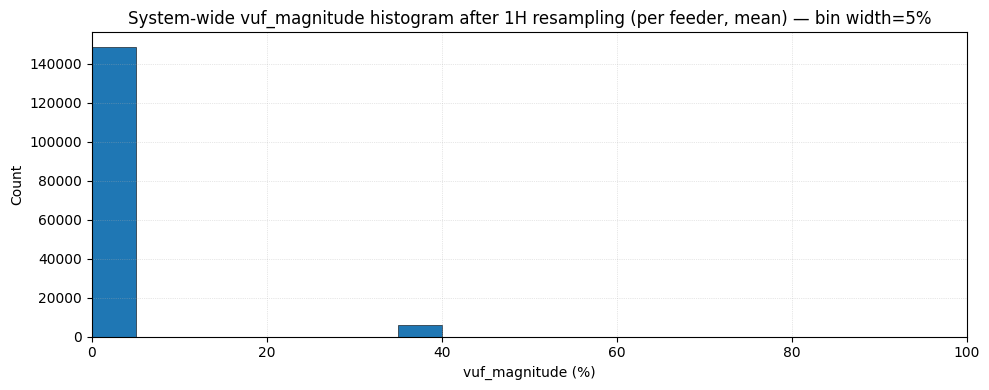

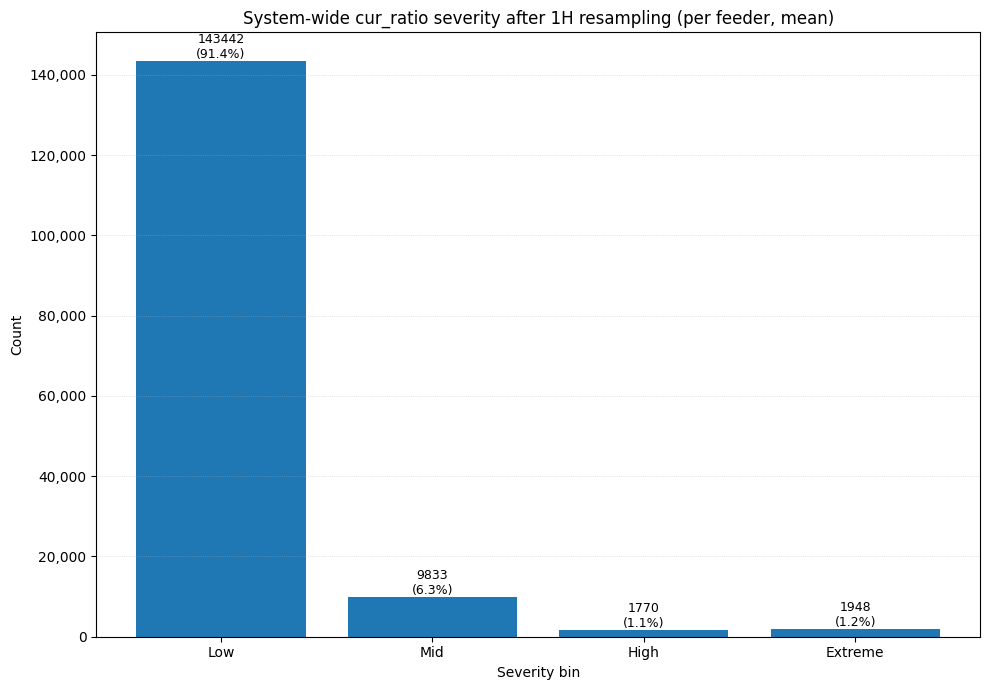

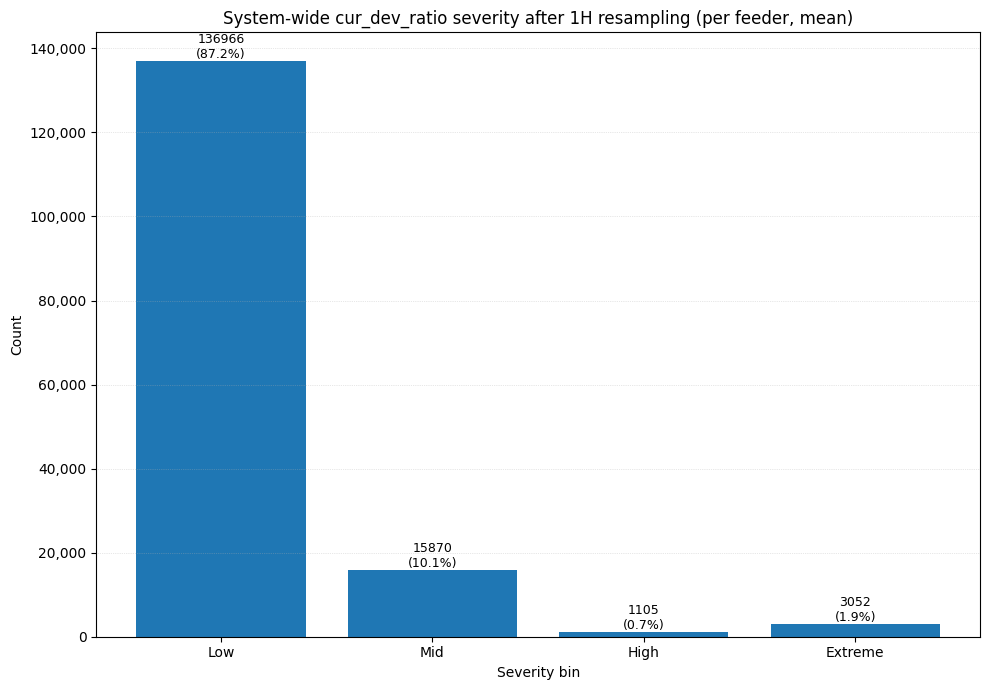

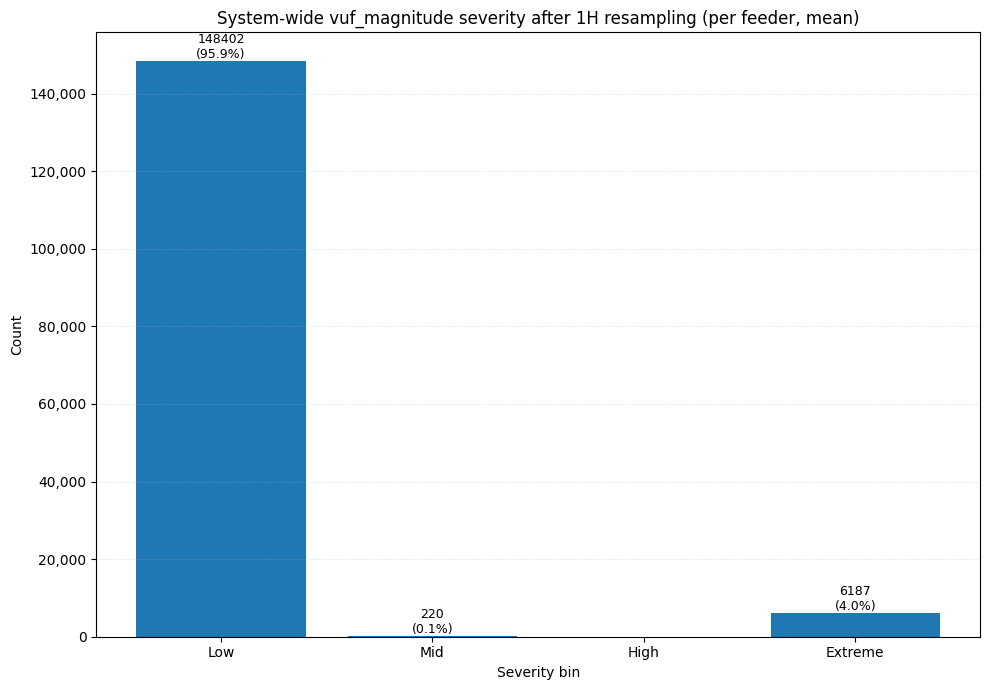

In [9]:

def system_wide_histogram_hourly(
    df_jn: pd.DataFrame,
    metric_col: str = "cur_ratio",
    bin_width_pct: float = 5.0,
    max_pct: float = 100.0,
    how: str = "mean",         # hourly aggregation: "mean" (default) or "median"
):
    """
    1) Resample imbalance metric from 15-min to 1-hour per feeder_id using mean/median.
    2) Plot histogram over the whole dataset (all devices, all hourly bins).

    Output distribution = { hourly-average metric values } across (device_id, hour).
    """

    if plt is None:
        print("matplotlib not available.")
        return None, None

    if "ts" not in df_jn.columns:
        raise ValueError("df_jn must contain a 'ts' column.")

    if "device_id" not in df_jn.columns:
        raise ValueError("df_jn must contain a 'device_id' column.")

    if metric_col not in df_jn.columns:
        raise ValueError(f"metric_col='{metric_col}' not found in df_jn.")

    tmp = df_jn[["device_id", "ts", metric_col]].copy()
    tmp["ts"] = pd.to_datetime(tmp["ts"])
    tmp["device_id"] = pd.to_numeric(tmp["device_id"], errors="coerce").astype("Int64")

    tmp[metric_col] = pd.to_numeric(tmp[metric_col], errors="coerce")
    tmp = tmp.dropna(subset=["device_id", "ts", metric_col])

    # ---- hourly aggregation per feeder ----
    tmp = tmp.set_index("ts").sort_index()

    if how == "median":
        hourly = (
            tmp.groupby("device_id")[metric_col]
               .resample("1h")
               .median()
               .dropna()
        )
    else:
        hourly = (
            tmp.groupby("device_id")[metric_col]
               .resample("1h")
               .mean()
               .dropna()
        )

    # hourly is a Series with MultiIndex (device_id, ts_hour)
    hourly_vals = hourly.to_numpy(dtype=float)

    # keep sane range
    hourly_vals = hourly_vals[(hourly_vals >= 0) & (hourly_vals <= max_pct)]
    if hourly_vals.size == 0:
        raise ValueError(f"No valid hourly {metric_col} values in [0, {max_pct}]")

    edges = np.arange(0, max_pct + bin_width_pct, bin_width_pct)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(hourly_vals, bins=edges, edgecolor="k", linewidth=0.4)
    ax.set_xlabel(f"{metric_col} (%)")
    ax.set_ylabel("Count")
    ax.set_title(
        f"System-wide {metric_col} histogram after 1H resampling "
        f"(per feeder, {how}) — bin width={bin_width_pct}%"
    )
    ax.set_xlim(0, max_pct)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
    fig.tight_layout()

    # Return both plot + the hourly series (useful for debugging / reuse)
    return fig, hourly

def system_wide_severity_barchart_hourly(
    df_jn: pd.DataFrame,
    metric_col: str = "cur_ratio",
    *,
    edges: Sequence[float],                  # e.g. [0, 20, 40, 60, 100.0 + 1e-9]
    labels: Optional[Sequence[str]] = None,  # e.g. ["Low","Mid","High","Extreme"]
    max_pct: float = 100.0,
    how: str = "mean",                       # "mean" or "median"
    annotate_percent: bool = True,
):
    """
    1) Resample metric from 15-min to 1-hour per feeder_id (mean/median).
    2) Bin hourly values into severity bins defined by `edges`.
    3) Plot bar chart: x-axis = bins, y-axis = count of hourly samples across all devices.

    Binning convention:
      - Uses right=False => intervals are [a, b)
      - Last edge should be > max_pct to include max_pct cleanly
    """
    if plt is None:
        print("matplotlib not available.")
        return None, None, None

    if "ts" not in df_jn.columns:
        raise ValueError("df_jn must contain a 'ts' column.")
    if "device_id" not in df_jn.columns:
        raise ValueError("df_jn must contain a 'device_id' column.")
    if metric_col not in df_jn.columns:
        raise ValueError(f"metric_col='{metric_col}' not found in df_jn.")

    edges = [float(x) for x in edges]
    if len(edges) < 3:
        raise ValueError("edges must have at least 3 values (e.g., [0, mid, max]).")
    if any(edges[i] >= edges[i + 1] for i in range(len(edges) - 1)):
        raise ValueError(f"edges must be strictly increasing. Got: {edges}")

    nbins = len(edges) - 1
    if labels is None:
        labels = [f"Bin{i+1}" for i in range(nbins)]
    else:
        labels = list(labels)
        if len(labels) != nbins:
            raise ValueError(f"labels must have length {nbins} (len(edges)-1). Got {len(labels)}")

    tmp = df_jn[["device_id", "ts", metric_col]].copy()
    tmp["ts"] = pd.to_datetime(tmp["ts"], errors="coerce")
    tmp["device_id"] = pd.to_numeric(tmp["device_id"], errors="coerce").astype("Int64")
    tmp[metric_col] = pd.to_numeric(tmp[metric_col], errors="coerce")
    tmp = tmp.dropna(subset=["device_id", "ts", metric_col])

    # ---- hourly aggregation per feeder ----
    tmp = tmp.set_index("ts").sort_index()

    how = how.lower().strip()
    if how == "median":
        hourly = tmp.groupby("device_id")[metric_col].resample("1h").median().dropna()
    elif how == "mean":
        hourly = tmp.groupby("device_id")[metric_col].resample("1h").mean().dropna()
    else:
        raise ValueError("how must be 'mean' or 'median'")

    hourly_vals = hourly.to_numpy(dtype=float)
    hourly_vals = hourly_vals[(hourly_vals >= 0) & (hourly_vals <= max_pct)]
    if hourly_vals.size == 0:
        raise ValueError(f"No valid hourly {metric_col} values in [0, {max_pct}]")

    # ---- bin into severity classes ----
    cats = pd.cut(
        hourly_vals,
        bins=edges,
        labels=labels,
        right=False,          # [a,b)
        include_lowest=True,
    )

    counts = pd.Series(cats).value_counts().reindex(labels, fill_value=0)
    total = int(counts.sum())

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.bar(labels, counts.to_numpy())
    ax.set_xlabel("Severity bin")
    ax.set_ylabel("Count")
    ax.set_title(f"System-wide {metric_col} severity after 1H resampling (per feeder, {how})")
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

    # force raw y-axis numbers (no 1e6)
    import matplotlib.ticker as mticker
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

    # annotate counts (+ percent), but skip empty bins
    for i, lab in enumerate(labels):
        v = int(counts.loc[lab])
        if v == 0:
            continue
        if annotate_percent:
            pct = (v / total * 100.0) if total > 0 else 0.0
            ax.text(i, v, f"{v}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
        else:
            ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    return fig, counts, hourly

edges_1h_CUR = [0.0, 20.0, 40.0, 60.0, 100.0 + 1e-9] # 1 hour severity edges for CUR
edges_1h_CURdev = [0.0, 10, 20, 30, (2/3)*100 + 1e-9]
edges_1h_VUF = [0.0, 1, 2, 3, 100 + 1e-9]
labels = ["Low", "Mid", "High", "Extreme"] 


fig, hourly_series = system_wide_histogram_hourly(
    df_jn_hi_load,
    metric_col="cur_ratio",
    bin_width_pct=5,
    max_pct=100,
    how="mean", 
)

# Example usage:
fig, hourly_series = system_wide_histogram_hourly(
    df_jn_hi_load,
    metric_col="cur_dev_ratio",
    bin_width_pct=5,
    max_pct=67,
    how="mean", 
)

fig, hourly_series = system_wide_histogram_hourly(
    df_jn_hi_load,
    metric_col="vuf_magnitude",
    bin_width_pct=5,
    max_pct=100,
    how="mean", 
)

fig, counts, hourly = system_wide_severity_barchart_hourly(
    df_jn_hi_load,
    metric_col="cur_ratio",
    edges=edges_1h_CUR,
    labels=labels,
    how="mean",
)

fig, counts, hourly = system_wide_severity_barchart_hourly(
    df_jn_hi_load,
    metric_col="cur_dev_ratio",
    edges=edges_1h_CURdev,
    labels=labels,
    how="mean",
)

fig, counts, hourly = system_wide_severity_barchart_hourly(
    df_jn_hi_load,
    metric_col="vuf_magnitude",
    edges=edges_1h_VUF,
    labels=labels,
    how="mean",
)

## Per a feeder

Here we look at the data per a feeder.

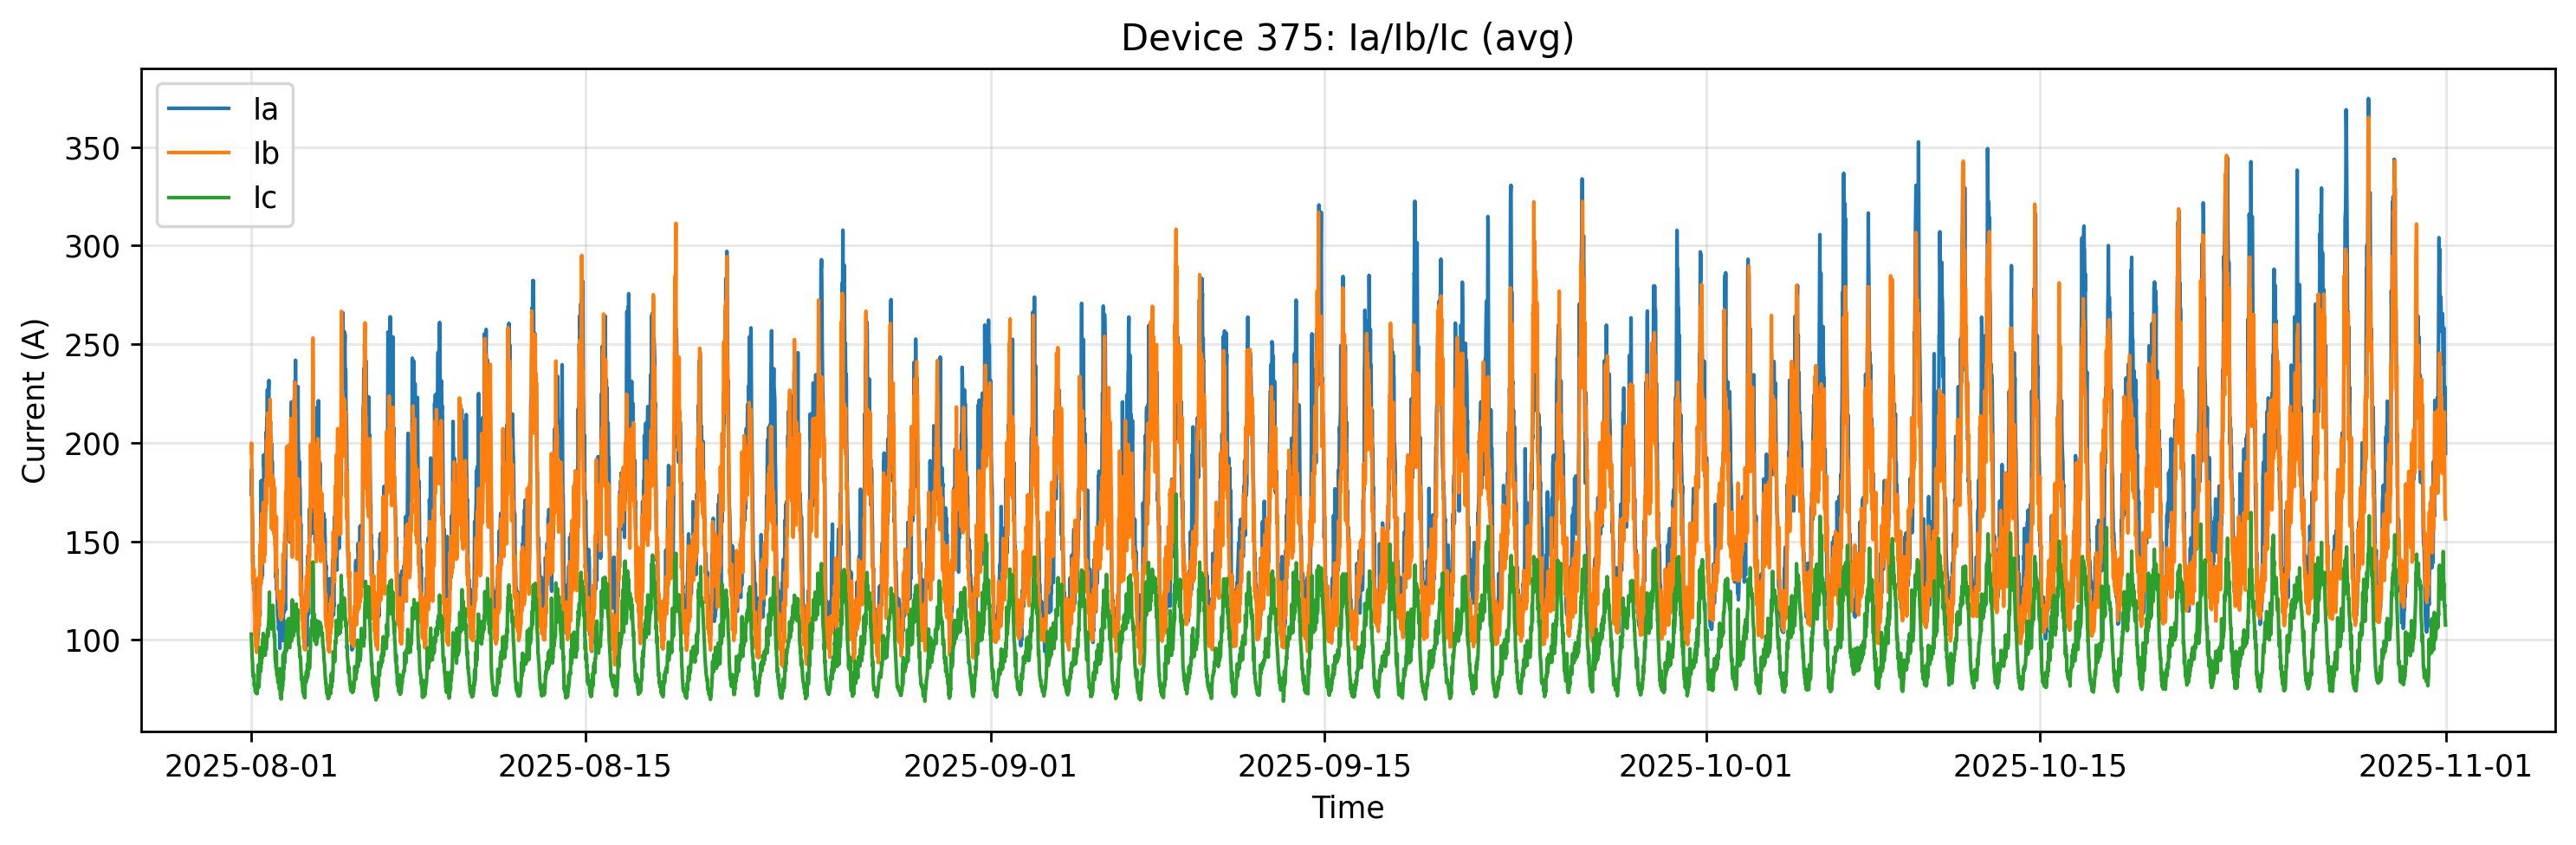

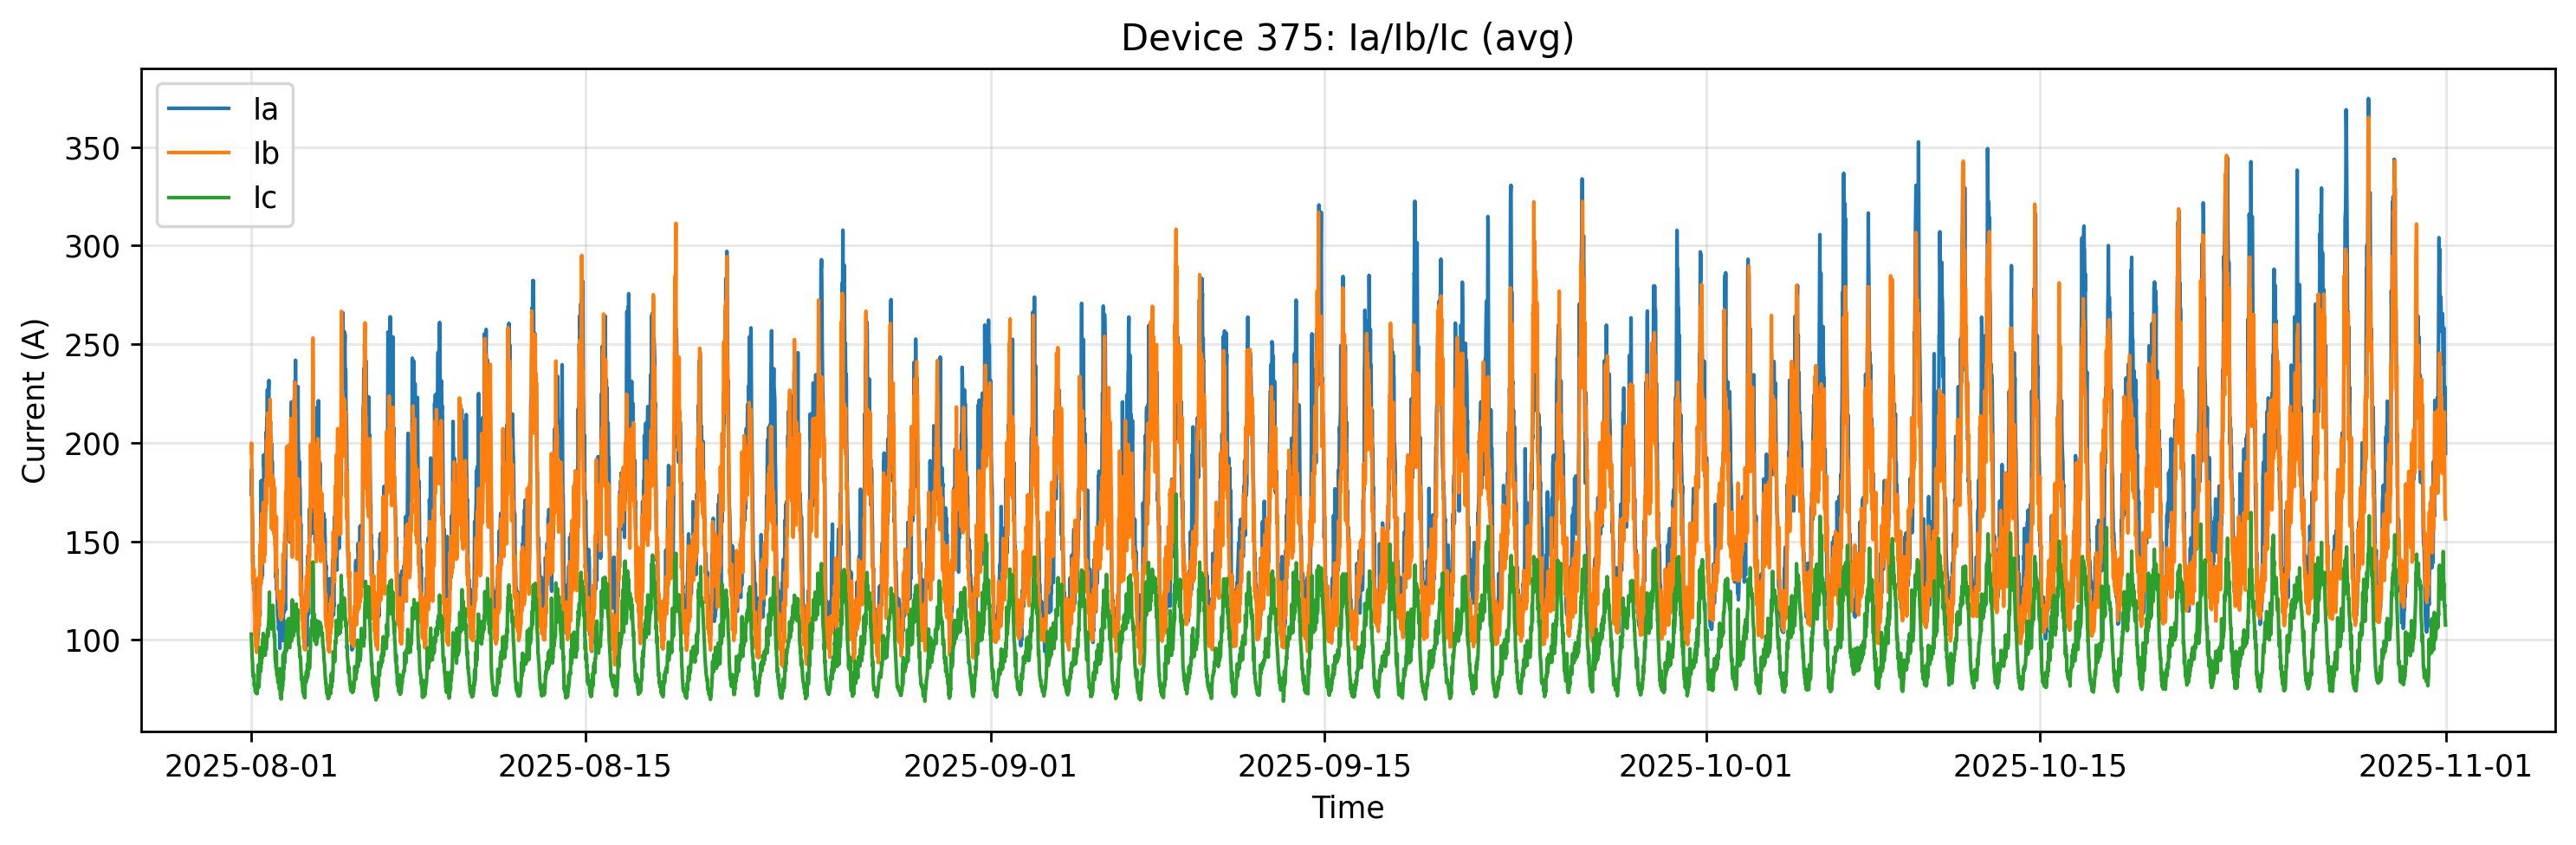

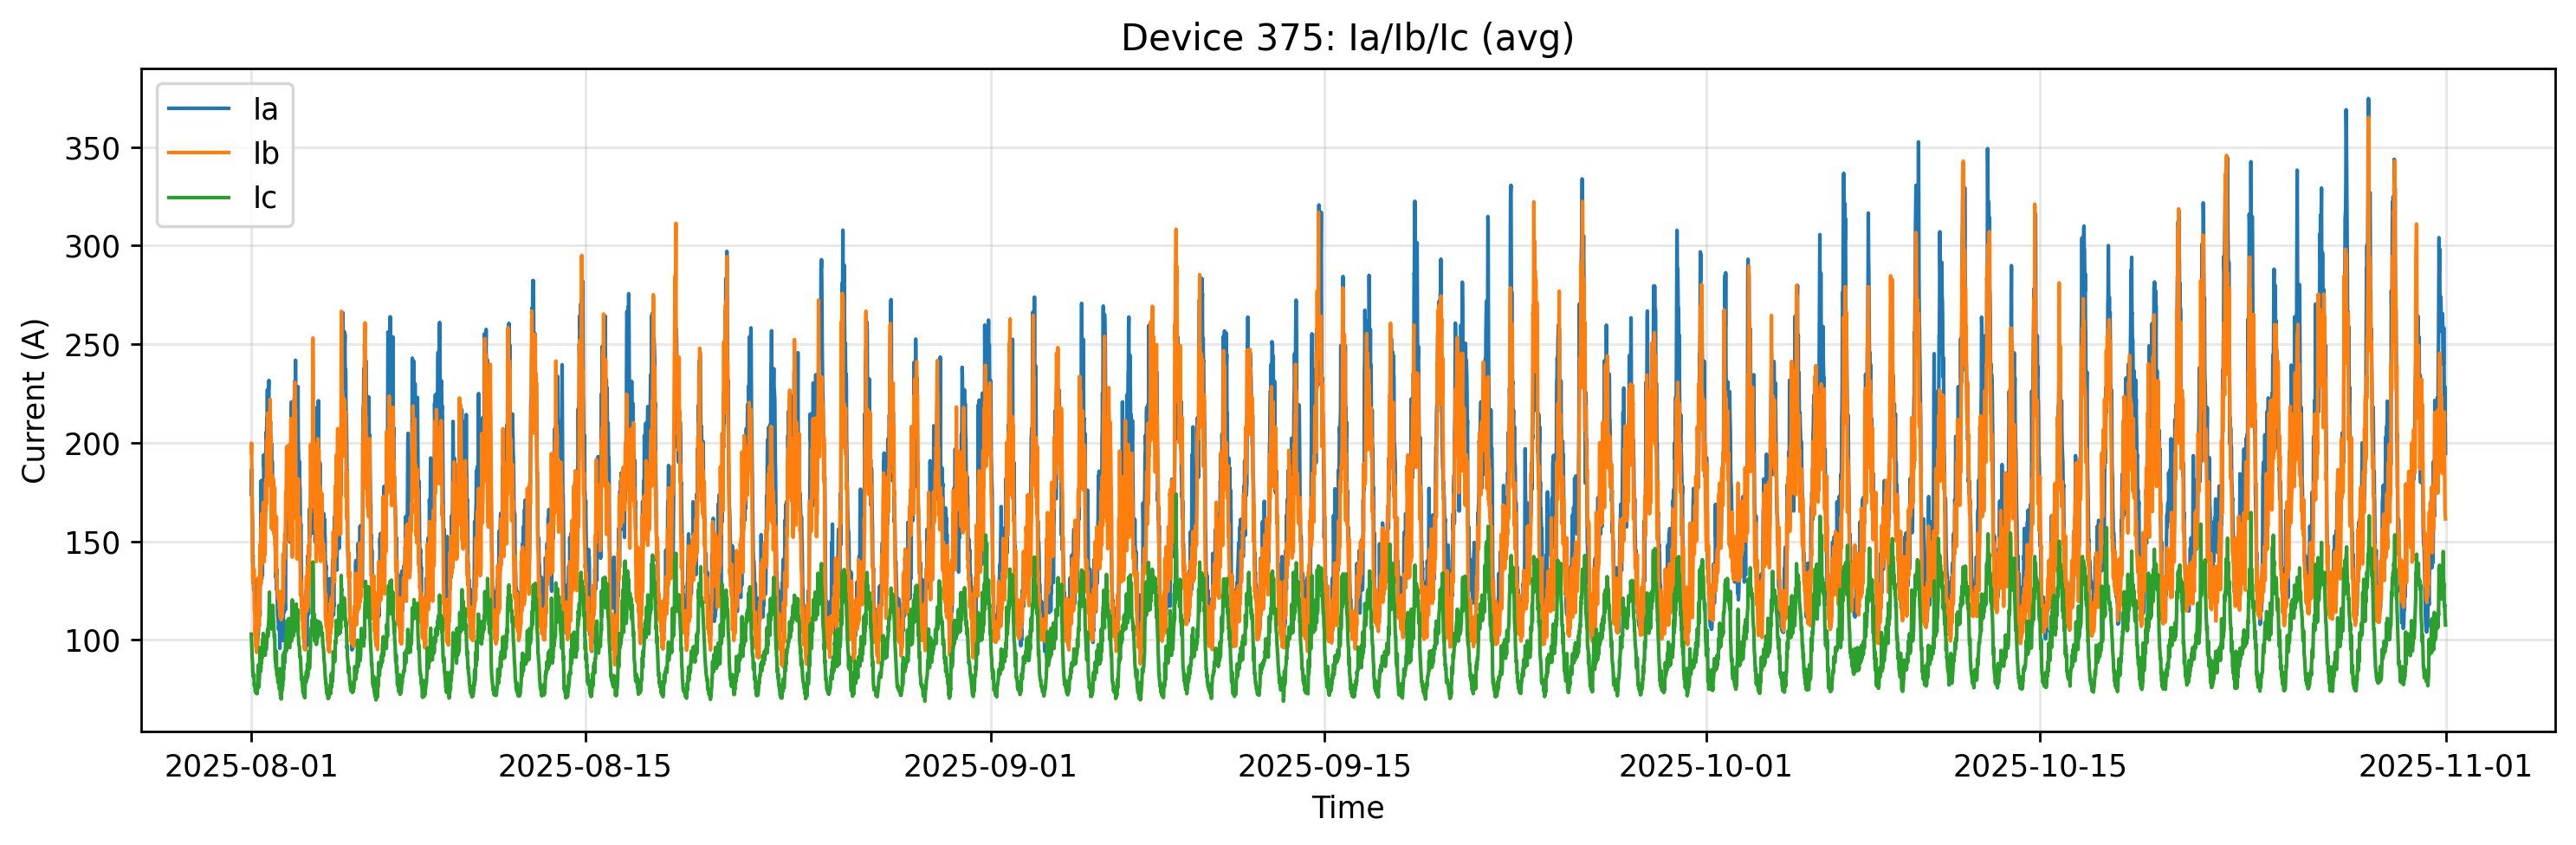

In [10]:



device_id = 375

metrics = ["cur_ratio", "cur_dev_ratio", "vuf_magnitude"]


for metric_col in metrics:
    if metric_col == "cur_ratio":
        thresholds = {"mild": 20, "moderate": 40, "severe": 60}  # percent
    elif metric_col == "cur_dev_ratio":
        thresholds = {"mild": 10, "moderate": 20, "severe": 30}  # percent
    elif metric_col == "vuf_magnitude":
        thresholds = {"mild": 1, "moderate": 2, "severe": 3}      # percent

    outdir = f"./figs/device_{device_id}/{metric_col}"

    df_ready, mild_events, metrics = make_7_plots_from_df_jn(
        df_jn,
        device_id=device_id,
        metric_col=metric_col,
        thresholds=thresholds,
        outdir=outdir,
        dpi=250,
        timebase="15min",
        stat="avg",
        scale="none",   )


In [11]:
def plot_device_currents(df_jn, device_id, start=None, end=None, dpi=150):
    """
    Plot Ia, Ib, Ic for a single device over a time period.
    
    Parameters:
    - df_jn: dataframe with columns device_id, ts, Ia_avg, Ib_avg, Ic_avg
    - device_id: device to plot
    - start: start timestamp (optional, e.g., "2025-01-01")
    - end: end timestamp (optional, e.g., "2025-01-31")
    - dpi: figure resolution
    
    Returns: matplotlib Figure
    """
    if plt is None:
        print("matplotlib not available; skipping plot.")
        return None
    
    # Select device
    df = df_jn[df_jn['device_id'] == device_id].copy()
    if df.empty:
        print(f"No data found for device_id={device_id}")
        return None
    
    # Convert timestamp
    df['ts'] = pd.to_datetime(df['ts'])
    
    # Filter by date range
    if start:
        start_ts = pd.to_datetime(start)
        # If df timestamps are timezone-aware and start_ts is naive, localize start_ts
        if df['ts'].dt.tz is not None and start_ts.tz is None:
            start_ts = start_ts.tz_localize(df['ts'].dt.tz)
        df = df[df['ts'] >= start_ts]
        
    if end:
        end_ts = pd.to_datetime(end)
        # If df timestamps are timezone-aware and end_ts is naive, localize end_ts
        if df['ts'].dt.tz is not None and end_ts.tz is None:
            end_ts = end_ts.tz_localize(df['ts'].dt.tz)
        df = df[df['ts'] <= end_ts]
    
    if df.empty:
        print(f"No data in time range for device_id={device_id}")
        return None
    
    # Sort by timestamp
    df = df.sort_values('ts')
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 5), dpi=dpi)
    ax.plot(df['ts'], df['Ia_avg'], linewidth=1.5, label='Ia', marker='o', markersize=2)
    ax.plot(df['ts'], df['Ib_avg'], linewidth=1.5, label='Ib', marker='s', markersize=2)
    ax.plot(df['ts'], df['Ic_avg'], linewidth=1.5, label='Ic', marker='^', markersize=2)
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Current (A)')
    ax.set_title(f'Device {device_id}: Phase Currents')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate(rotation=45, ha='right')
    fig.tight_layout()
    
    return fig


# Example usage:
fig = plot_device_currents(df_jn, device_id=386, start="2025-11-01", end="2025-11-04", dpi=300)

No data found for device_id=386


```mermaid
graph TD;

%% Pipeline for Imbalance Metrics (Mermaid-safe labels: avoid parentheses)

A1[Fetch device inventory<br/>→ devices.csv] --> A2[Fetch capability/channel mapping<br/>→ capabilities.csv];

A2 --> B1[Initialize scraper run<br/>time window, 15-min grid, metrics list];

B1 --> B2{Loop over device_id<br/>from devices.csv};
B2 --> B3[Resolve measurements via capabilities.csv<br/>select min/avg/max];
B3 --> B4[Fetch raw data min/avg/max<br/>JSON];
B4 --> B5[Parse JSON → dataframe<br/>timestamp index, standard columns];

B5 --> C1[QC + alignment<br/>snap to 15-min grid<br/>handle missing/duplicates<br/>sanity checks];
C1 --> C2[Compute imbalance metrics per timestep<br/>CUR, CURdev, VUFmag, ...];
C2 --> C3[Write analysis dataset<br/>→ parquet];

C3 --> D1[Load parquet in report script];
D1 --> D2[Aggregate + generate insights & figures<br/>histograms, rankings, example feeders,<br/>severity summaries];

```

In [12]:
# --- compute per-device timeframe from df_jn ---
tmp = df_jn_filtered[["device_id", "ts", "name", "device_type_name"]].copy()
tmp["device_id"] = pd.to_numeric(tmp["device_id"], errors="coerce").astype("Int64")
tmp["ts"] = pd.to_datetime(tmp["ts"], errors="coerce")
tmp = tmp.dropna(subset=["device_id", "ts"])

# first/last per device
tf = (
    tmp.groupby("device_id")
       .agg(
           first_ts=("ts", "min"),
           last_ts=("ts", "max"),
           name=("name", "first"),
           device_type_name=("device_type_name", "first"),
           n_samples=("ts", "count"),
       )
       .reset_index()
)

tf["duration"] = tf["last_ts"] - tf["first_ts"]
tf["duration_days"] = tf["duration"].dt.total_seconds() / 86400.0

# --- top 5 shortest / longest timeframes ---
shortest5 = tf.sort_values(["duration", "n_samples"], ascending=[True, True]).head(200)
longest5  = tf.sort_values(["duration", "n_samples"], ascending=[False, False]).head(10)

print("\nTop 5 SHORTEST device timeframes:")
display(shortest5[["device_id", "name", "device_type_name", "first_ts", "last_ts", "duration", "duration_days", "n_samples"]])

print("\nTop 5 LONGEST device timeframes:")
display(longest5[["device_id", "name", "device_type_name", "first_ts", "last_ts", "duration", "duration_days", "n_samples"]])

#


Top 5 SHORTEST device timeframes:


,device_id,name,device_type_name,first_ts,last_ts,duration,duration_days,n_samples
48,360,D1441 SP1 L1,UMG 96RM-E,2025-09-24 16:17:33+00:00,2025-10-31 23:45:00+00:00,37 days 07:27:27,37.310729,3583
1,4,D0029 SP1 L1 / D0029 Borgartún 20 SP1 L1 / Mea...,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-09-25 05:30:00+00:00,55 days 05:30:00,55.229167,5277
9,132,D0670 SP1 L1,UMG 605,2025-08-01 00:00:00.200129476+00:00,2025-10-31 23:45:00.133601666+00:00,91 days 23:44:59.933472190,91.989583,8832
38,323,D1534 SP1 L1,UMG 512,2025-07-31 23:59:00.159895718+00:00,2025-10-31 23:44:00.118920582+00:00,91 days 23:44:59.959024864,91.989583,8832
11,134,D0688 SP1 L1,UMG 605,2025-07-31 23:59:00.159080464+00:00,2025-10-31 23:44:00.122765060+00:00,91 days 23:44:59.963684596,91.989583,8832
...,...,...,...,...,...,...,...,...
78,436,D0707 SP1 L1,UMG 96-PQ-L,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
80,448,D1056 SP1 L1 / UMG801-4700-2674 / Measurement ...,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
81,456,D1029 SP1 L1 / UMG801-4700-2804 / Measurement ...,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
82,462,D1025 SP1 L1,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832



Top 5 LONGEST device timeframes:


,device_id,name,device_type_name,first_ts,last_ts,duration,duration_days,n_samples
39,324,D1534 SP2 L1,UMG 512,2025-07-31 23:59:00.159907868+00:00,2025-10-31 23:45:00.141873128+00:00,91 days 23:45:59.981965260,91.990278,17574
0,1,D0029 SP1 L2,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
2,12,D0411 SP1 L1 / D0411 Grensásvegur 1 SP1 L1 / M...,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
12,144,D1484 SP1 L1,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
13,145,D0074 SP1 L1,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
14,146,D0074 SP2 L1,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
16,155,D1160 SP1 L1,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
17,156,D1159 SP1 L1,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
18,157,D1329 SP1 L1,UMG 96RM-E,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
21,177,D1457 SP2 L1 / UMG801-4700-2680 / Measurement ...,UMG 801 Measurement Group,2025-08-01 00:00:00+00:00,2025-10-31 23:45:00+00:00,91 days 23:45:00,91.989583,8832
